In [2]:
from helpers import ObserveAttentionHelper

import matplotlib.pyplot as plt
import torch
import numpy as np
import random
from tqdm import tqdm
import pandas as pd;

/home/mohsen/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/mohsen/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_name = "meta-llama/Llama-3.2-3B-Instruct"
max_new_tokens = 10000
prompt = """
Write a detailed essay on the history of artificial intelligence, covering key milestones, influential researchers, and major breakthroughs in the field. Discuss the evolution of AI from its inception to the present day, including the development of machine learning, deep learning, and neural networks. Highlight the impact of AI on various industries and society as a whole, as well as ethical considerations and future prospects for AI technology.
"""
observer = ObserveAttentionHelper(model_name, max_new_tokens=max_new_tokens)
observer.run_model(prompt)

In [ ]:
attn_info = observer.get_attention_info()
attn_info

{'num_layers': 28,
 'num_q_heads': 24,
 'num_kv_heads': 8,
 'head_dim': 128,
 'prompt_length': 81,
 'num_generated': 10000,
 'total_tokens': 10081,
 'uses_gqa': True}

In [ ]:
def topk_threshold(scores: torch.Tensor, k: int = 16):
    # get top k of scores
    topk_vals, _ = torch.topk(scores, k=k)

    # get the minimum value in the top k
    threshold = topk_vals.min().item()

    return threshold


def sample_max_threshold(scores, sample_size=200):
    # sample a subset of scores
    indices = torch.randperm(scores.shape[0])[:sample_size]
    sampled_scores = scores[indices]

    # return the max of the sampled scores
    return sampled_scores.max().item()


def sample_mean_topk_threshold(scores, sample_size=200, k=16):
    # sample a subset of scores
    indices = torch.randperm(scores.shape[0])[:sample_size]
    sampled_scores = scores[indices]

    mean = sampled_scores.mean().item()
    topk_vals, _ = torch.topk(scores, k=k)
    topk_mean = topk_vals.mean().item()

    return (mean + topk_mean) / 2

In [ ]:
token_ids = [1000, 1500, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 9999]
layer_idx = 20  # shouldn't matter

results = {
    "token_id": [],
    "method": [],
    "threshold": [],
    "fraction": [],
    "count": [],
}

for token_id in token_ids:
    print(f"Processing token_id: {token_id}")
    stats = observer.get_stats_at_token(token_id)[layer_idx]
    scores = None
    for head in range(attn_info["num_q_heads"]):
        if scores is None:
            scores = stats[head]["scores"]
        else:
            scores += stats[head]["scores"]
    scores /= attn_info["num_q_heads"]

    # top k
    for k in [16, 32, 64]:
        threshold = topk_threshold(scores, k=k)
        count = (scores >= threshold).sum().item()
        results["token_id"].append(token_id)
        results["method"].append(f"top_{k}")
        results["threshold"].append(threshold)
        results["count"].append(count)
        results["fraction"].append(count / scores.shape[0])

    # sample max
    for sample_size in [128, 256, 512, 1024]:
        threshold = sample_max_threshold(scores, sample_size=sample_size)
        count = (scores >= threshold).sum().item()
        results["token_id"].append(token_id)
        results["method"].append(f"sample_max_{sample_size}")
        results["threshold"].append(threshold)
        results["count"].append(count)
        results["fraction"].append(count / scores.shape[0])

    # sample mean + topk mean
    for sample_size in [128, 256, 512, 1024]:
        threshold = sample_mean_topk_threshold(scores, sample_size=sample_size, k=16)
        count = (scores >= threshold).sum().item()
        results["token_id"].append(token_id)
        results["method"].append(f"sample_mean_topk_{sample_size}")
        results["threshold"].append(threshold)
        results["count"].append(count)
        results["fraction"].append(count / scores.shape[0])

df = pd.DataFrame(results)
df.to_csv("threshold_results.csv", index=False)

Processing token_id: 1000
Processing token_id: 1500
Processing token_id: 2000
Processing token_id: 3000
Processing token_id: 4000
Processing token_id: 5000
Processing token_id: 6000
Processing token_id: 7000
Processing token_id: 8000
Processing token_id: 9000
Processing token_id: 9999


### Insights

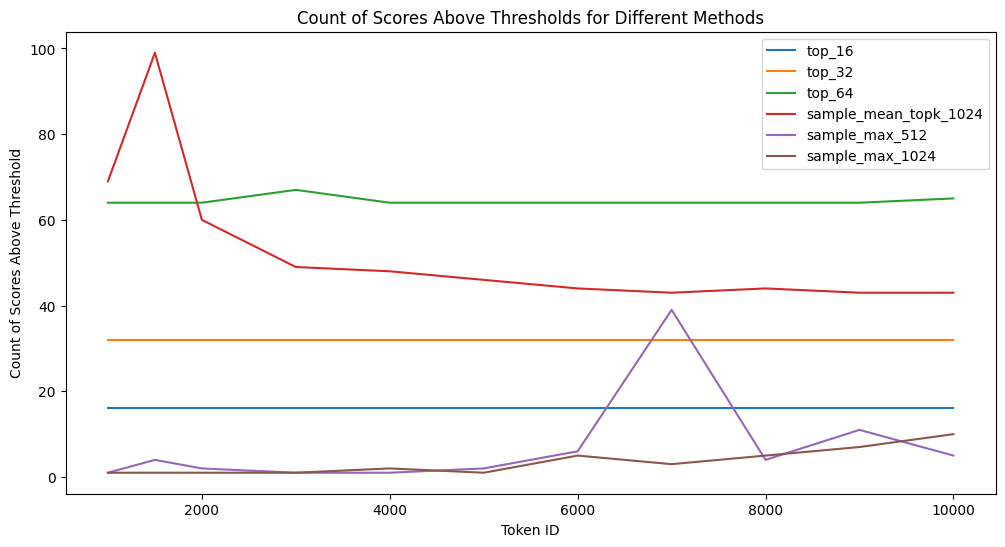

In [ ]:
plt.figure(figsize=(12, 6))

methods_list = (
    [f"top_{k}" for k in [16, 32, 64]]
    # + [f"sample_max_{sample_size}" for sample_size in [128, 256, 512, 1024]]
    + [f"sample_mean_topk_{sample_size}" for sample_size in [128, 256, 512, 1024]]
    # + ["sample_mean_topk_1024", "sample_max_512", "sample_max_1024"]
)

for method in methods_list:
    tmp = df[df["method"] == method]
    plt.plot(tmp["token_id"], tmp["count"], label=method)

plt.xlabel("Token ID")
plt.ylabel("Count of Scores Above Threshold")
plt.title("Count of Scores Above Thresholds for Different Methods")
plt.legend()
plt.show()

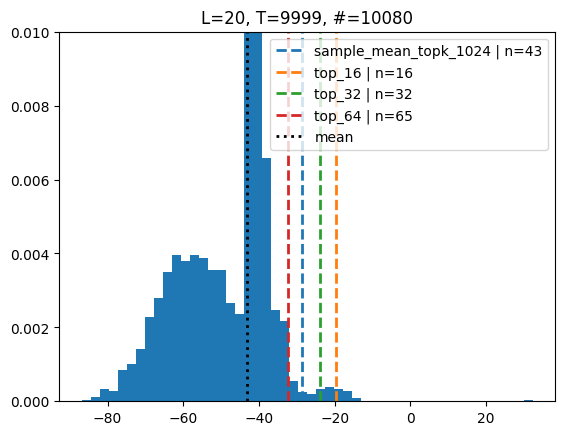

In [120]:
token_idx = 9999
stats = observer.get_stats_at_token(token_idx)[layer_idx]
scores = None
for head in range(attn_info["num_q_heads"]):
    if scores is None:
        scores = stats[head]["scores"]
    else:
        scores += stats[head]["scores"]

# Main plotting line:
scores = scores / attn_info["num_q_heads"]  # Average over heads
# plt.plot(scores.sort().values.tolist()[::-1])
plt.hist(scores.tolist(), bins=50, density=True)
plt.ylim(0, 0.01)

# Add one vertical line per method
colors = plt.cm.tab10.colors  # 10 distinct colors
for i, method in enumerate(
    [
        "sample_mean_topk_1024",
        # "sample_mean_topk_256",
        "top_16",
        "top_32",
        "top_64",
    ]
):
    threshold = df[(df["token_id"] == token_idx) & (df["method"] == method)][
        "threshold"
    ].values[0]

    count = scores[scores >= threshold].shape[0]

    plt.axvline(
        # plt.axhline(
        threshold,
        linestyle="--",
        linewidth=2,
        label=f"{method} | n={count}",
        color=colors[i % len(colors)],
    )

plt.axvline(
    scores.mean().item(), linestyle=":", linewidth=2, label="mean", color="black"
)

plt.title(f"L={layer_idx}, T={token_idx}, #={len(scores)}")
plt.legend()
plt.show()